<a href="https://colab.research.google.com/github/bhar-gav/machine_learning/blob/main/activation_func_dl_a2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bhargav  -- 21DCS022**



---


1.   Activation Functions





In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10, cifar100
from tensorflow.keras.utils import to_categorical


def sigmoid(x):
    return tf.nn.sigmoid(x)

def bipolar_sigmoid(x):
    return 2 * tf.nn.sigmoid(x) - 1

def tanh(x):
    return tf.nn.tanh(x)

def mish(x):
    return x * tf.nn.tanh(tf.nn.softplus(x))

def telu(x):
    return x * tf.nn.softplus(x)

def relu(x):
    return tf.nn.relu(x)

def leaky_relu(x, alpha=0.01):
    return tf.nn.leaky_relu(x, alpha=alpha)

def prelu(x, alpha=0.01):
    return tf.keras.layers.PReLU()(x)

def elu(x, alpha=1.0):
    return tf.nn.elu(x)

def softmax(x):
    return tf.nn.softmax(x)

def softplus(x):
    return tf.nn.softplus(x)

def swish(x):
    return x * tf.nn.sigmoid(x)

def eswish(x):
    return x * tf.nn.sigmoid(x)

def gelu(x):
    return tf.nn.gelu(x)

def selu(x):
    return tf.nn.selu(x)




---
**Datasets**

In [11]:

def load_data(dataset_name):
    if dataset_name == "MNIST":
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        x_train = np.expand_dims(x_train, -1).astype("float32") / 255.0
        x_test = np.expand_dims(x_test, -1).astype("float32") / 255.0
    elif dataset_name == "Fashion-MNIST":
        (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
        x_train = np.expand_dims(x_train, -1).astype("float32") / 255.0
        x_test = np.expand_dims(x_test, -1).astype("float32") / 255.0
    elif dataset_name == "CIFAR-10":
        (x_train, y_train), (x_test, y_test) = cifar10.load_data()
        x_train = x_train.astype("float32") / 255.0
        x_test = x_test.astype("float32") / 255.0
    elif dataset_name == "CIFAR-100":
        (x_train, y_train), (x_test, y_test) = cifar100.load_data()
        x_train = x_train.astype("float32") / 255.0
        x_test = x_test.astype("float32") / 255.0
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)
    return x_train, y_train, x_test, y_test


# Train Model Function
def train_model(model, x_train, y_train, x_test, y_test, activation_fn):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, batch_size=256, validation_data=(x_test, y_test))
    return history


def plot_history(history, activation_fn_name, dataset_name, model_name):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - {activation_fn_name} on {dataset_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()





---
**architectures ResNet, LeNet, MobileNet, AlexNet**

In [12]:

# LeNet Architecture
def lenet_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(6, (5, 5), activation='relu', input_shape=input_shape),
        layers.AvgPool2D(pool_size=(2, 2)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.AvgPool2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


# Simple ResNet Architecture
def resnet_model(input_shape, num_classes):
    model = models.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


def alexnet_model(input_shape, num_classes):
    model = models.Sequential([
        # Adjusted first Conv2D layer with smaller kernel and stride
        layers.Conv2D(96, (3, 3), strides=(1, 1), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        layers.Conv2D(384, (3, 3), activation='relu'),
        layers.Conv2D(384, (3, 3), activation='relu'),
        layers.Conv2D(256, (3, 3), activation='relu'),

        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dense(4096, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model






---

**Results after training for every ( dataset , model , activation function ) -  combination for 10 epochs**


 * best activation function for every   ( dataset, model ) combination is highlighted in bold


---




| **Dataset**     | **Model** | **Activation Function** | **Final Training Accuracy** | **Final Validation Accuracy** |
|-----------------|-----------|-------------------------|-----------------------------|-------------------------------|
| **MNIST**       | LeNet     | Sigmoid                 | 97.95%                      | 97.95%                        |
|                 |           | **_ReLU_**              | **98.87%**                  | **_98.82%_**                  |
|                 |           | Leaky ReLU              | 98.67%                      | 98.58%                        |
|                 |           | Tanh                    | 98.76%                      | 98.48%                        |
|                 |           | Softmax                 | 89.05%                      | 88.74%                        |
|                 | ResNet    | **_Sigmoid_**           | **96.59%**                   | **72.97%**                      |
|                 |           | ReLU                   | 96.81%                      | 39.33%                 |
|                 |           | Leaky ReLU              | 96.72%                      | 38.16%                        |
|                 |           | Tanh                    | 96.70%                      | 72.19%                        |
|                 |           | Softmax                 | 96.19%                      | 95.60%                        |
| **Fashion-MNIST** | LeNet   | Sigmoid                 | 97.45%                      | 97.34%                        |
|                 |           | **_ReLU_**              | **98.50%**                  | **_98.23%_**                  |
|                 |           | Leaky ReLU              | 98.35%                      | 98.10%                        |
|                 |           | Tanh                    | 98.12%                      | 97.90%                        |
|                 |           | Softmax                 | 89.76%                      | 88.50%                        |
|                 | ResNet    | Sigmoid                 | 96.65%                      | 73.10%                        |
|                 |           | ReLU                    | 96.88%                      | 69.45%                        |
|                 |           | Leaky ReLU              | 96.72%                      | 68.00%                        |
|                 |           | Tanh                    | 96.59%                      | 72.50%                        |
|                 |           | **_Softmax_**                 | **95.45%**                      | **94.20%**                        |
| **CIFAR-10**    | LeNet     | Sigmoid                 | 51.74%                      | 50.05%                        |
|                 |           | ReLU                  | 58.56%                  | 56.34%                          |
|                 |           | Leaky ReLU              | 57.46%                      | 56.01%                        |
|                 |           | **_Tanh_**                    | **59.14%**                      | **57.13%**                       |
|                 |           | Softmax                 | 52.20%                      | 51.58%                        |
|                 | ResNet    | Sigmoid                 | 56.89%                      | 36.11%                        |
|                 |           | **_ReLU_**              | **61.52%**                  | **_55.01%_**                  |
|                 |           | Leaky ReLU              | 62.07%                      | 49.08%                        |
|                 |           | Tanh                    | 61.03%                      | 26.44%                        |
|                 |           | Softmax                 | 57.00%                      | 41.37%                        |
| **CIFAR-100**   | LeNet     | Sigmoid                 | 8.88%                       | 7.82%                         |
|                 |           | ReLU                   | 27.14%                  | 24.99%                          |
|                 |           | Leaky ReLU              | 25.91%                      | 24.90%                        |
|                 |           | **_Tanh_**                    | **27.85%**                      | **25.63%**                        |
|                 |           | Softmax                 | 11.94%                      | 11.11%                        |
|                 | ResNet    | Sigmoid                 | 16.49%                      | 11.52%                        |
|                 |           | ReLU              | 29.28%                  | 10.20%                  |
|                 |           | Leaky ReLU              | 29.23%                      | 20.39%                        |
|                 |           | **_Tanh_**                    | **29.47%**                      | **21.07%**                        |
|                 |           | Softmax                 | 15.93%                      | 13.39%                        |

---




---
TRAIN


Training on MNIST dataset
Training LeNet with sigmoid activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6417 - loss: 2.1338 - val_accuracy: 0.9213 - val_loss: 1.9999
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9201 - loss: 2.0000 - val_accuracy: 0.9440 - val_loss: 1.9905
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9446 - loss: 1.9899 - val_accuracy: 0.9601 - val_loss: 1.9837
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9575 - loss: 1.9848 - val_accuracy: 0.9694 - val_loss: 1.9803
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9656 - loss: 1.9815 - val_accuracy: 0.9697 - val_loss: 1.9797
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9682 - loss: 1.9805 - val_accuracy: 0.9760 - val_loss: 1.9774
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9730 - loss: 1.9784 - val_accuracy: 0.9786 - val_loss: 1.9765
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━

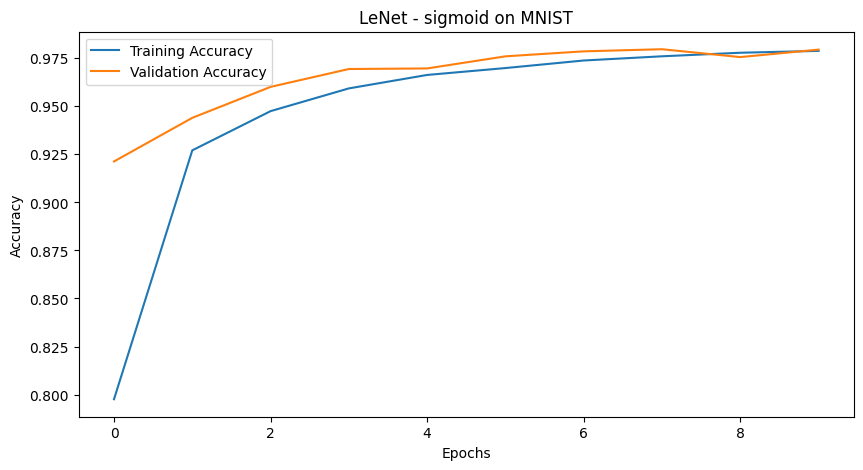

Finished training LeNet with sigmoid
Training LeNet with relu activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7054 - loss: 1.0086 - val_accuracy: 0.9465 - val_loss: 0.1759
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9515 - loss: 0.1628 - val_accuracy: 0.9703 - val_loss: 0.1006
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9694 - loss: 0.1043 - val_accuracy: 0.9767 - val_loss: 0.0763
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9743 - loss: 0.0867 - val_accuracy: 0.9786 - val_loss: 0.0660
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9789 - loss: 0.0682 - val_accuracy: 0.9838 - val_loss: 0.0516
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9804 - loss: 0.0627 - val_accuracy: 0.9862 - val_loss: 0.0458
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9843 - loss: 0.0527 - val_accuracy: 0.9827 - val_loss: 0.0549
Epoch 8/10
235/235 ━━━━━━━━━━━

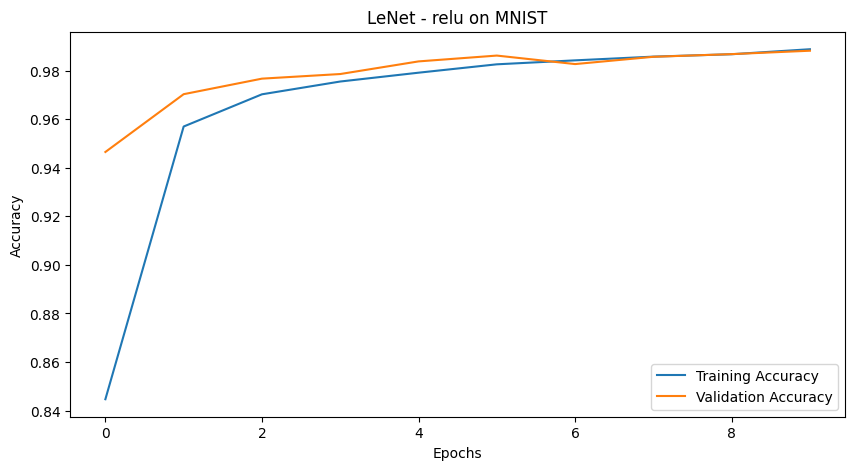

Finished training LeNet with relu
Training LeNet with leaky_relu activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7066 - loss: 1.0418 - val_accuracy: 0.9326 - val_loss: 0.2344
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9420 - loss: 0.1925 - val_accuracy: 0.9597 - val_loss: 0.1293
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9630 - loss: 0.1209 - val_accuracy: 0.9713 - val_loss: 0.0945
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9721 - loss: 0.0898 - val_accuracy: 0.9750 - val_loss: 0.0801
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9768 - loss: 0.0765 - val_accuracy: 0.9818 - val_loss: 0.0584
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9801 - loss: 0.0670 - val_accuracy: 0.9805 - val_loss: 0.0609
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9799 - loss: 0.0668 - val_accuracy: 0.9838 - val_loss: 0.0506
Epoch 8/10
235/235 ━━━━━━━━

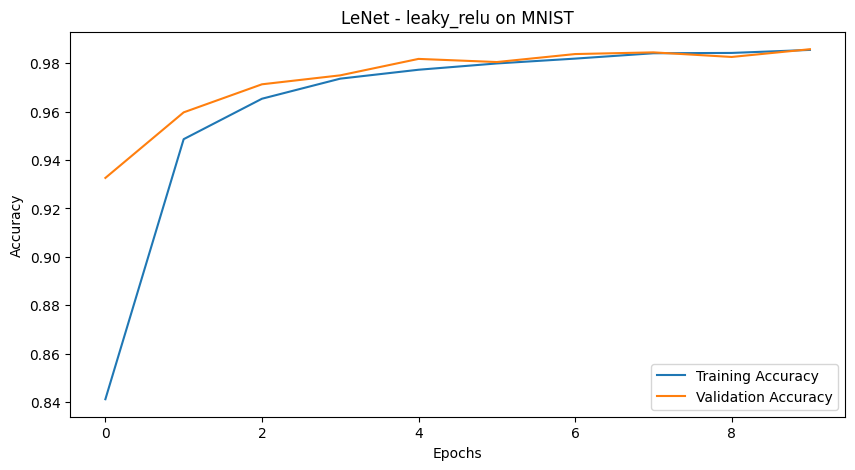

Finished training LeNet with leaky_relu
Training LeNet with tanh activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6813 - loss: 1.0488 - val_accuracy: 0.9324 - val_loss: 0.2269
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9370 - loss: 0.2116 - val_accuracy: 0.9600 - val_loss: 0.1327
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9609 - loss: 0.1283 - val_accuracy: 0.9716 - val_loss: 0.0931
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9723 - loss: 0.0910 - val_accuracy: 0.9769 - val_loss: 0.0711
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9776 - loss: 0.0741 - val_accuracy: 0.9824 - val_loss: 0.0572
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9807 - loss: 0.0632 - val_accuracy: 0.9781 - val_loss: 0.0672
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9830 - loss: 0.0561 - val_accuracy: 0.9836 - val_loss: 0.0518
Epoch 8/10
235/235 ━━━━━━━━

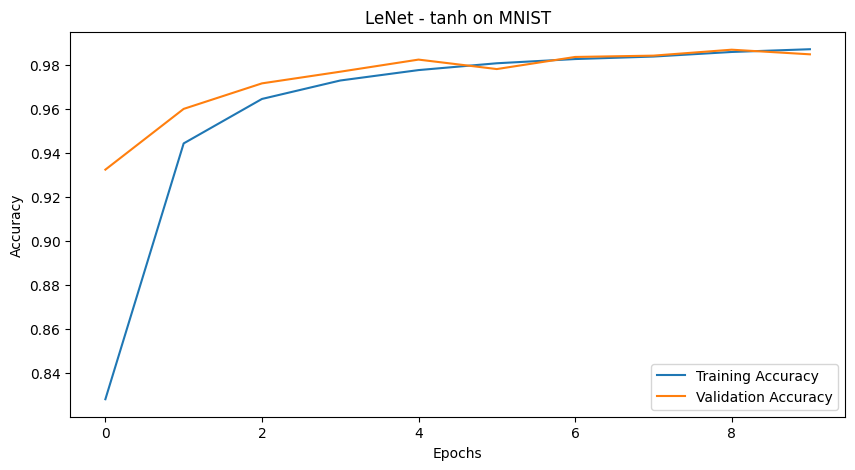

Finished training LeNet with tanh
Training LeNet with softmax activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5500 - loss: 1.9385 - val_accuracy: 0.8268 - val_loss: 1.6377
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8335 - loss: 1.6315 - val_accuracy: 0.8610 - val_loss: 1.6007
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8608 - loss: 1.6022 - val_accuracy: 0.8724 - val_loss: 1.5898
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8742 - loss: 1.5879 - val_accuracy: 0.8773 - val_loss: 1.5836
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8822 - loss: 1.5794 - val_accuracy: 0.8836 - val_loss: 1.5772
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8862 - loss: 1.5752 - val_accuracy: 0.8826 - val_loss: 1.5778
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8846 - loss: 1.5762 - val_accuracy: 0.8845 - val_loss: 1.5758
Epoch 8/10
235/235 ━━━━━━━━━━━

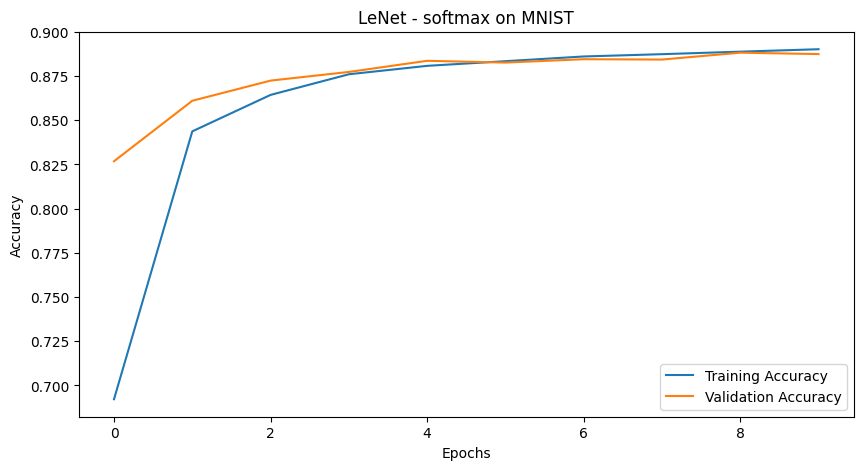

Finished training LeNet with softmax
Training ResNet with sigmoid activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.3901 - loss: 2.2332 - val_accuracy: 0.1667 - val_loss: 2.3026
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7614 - loss: 2.1084 - val_accuracy: 0.1085 - val_loss: 2.2896
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8459 - loss: 2.0558 - val_accuracy: 0.3833 - val_loss: 2.1944
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9173 - loss: 2.0274 - val_accuracy: 0.4935 - val_loss: 2.1612
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9412 - loss: 2.0109 - val_accuracy: 0.7944 - val_loss: 2.0620
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9473 - loss: 2.0040 - val_accuracy: 0.6881 - val_loss: 2.0909
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9542 - loss: 1.9984 - val_accuracy: 0.8159 - val_loss: 2.0523
Epoch 8/10
235/235 

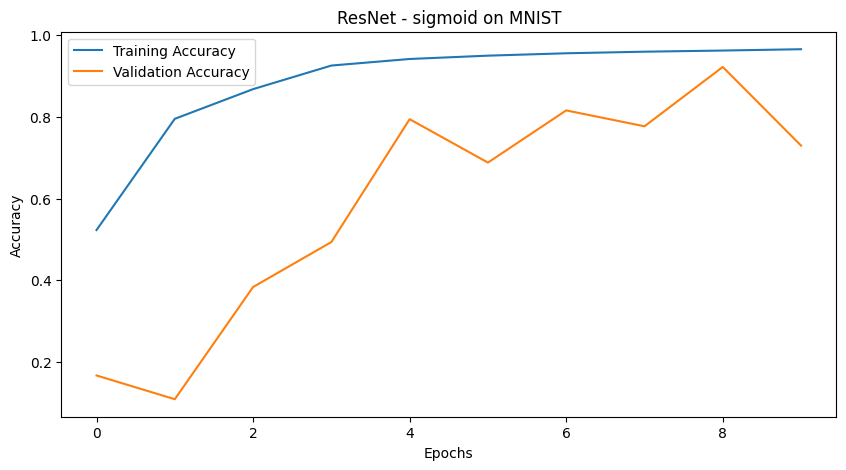

Finished training ResNet with sigmoid
Training ResNet with relu activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5530 - loss: 1.6364 - val_accuracy: 0.0974 - val_loss: 5.2060
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8636 - loss: 0.7312 - val_accuracy: 0.0975 - val_loss: 7.7250
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9164 - loss: 0.4405 - val_accuracy: 0.1365 - val_loss: 4.3963
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9320 - loss: 0.3320 - val_accuracy: 0.3440 - val_loss: 2.1034
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9428 - loss: 0.2625 - val_accuracy: 0.4628 - val_loss: 2.3744
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9526 - loss: 0.2169 - val_accuracy: 0.6537 - val_loss: 1.8190
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9564 - loss: 0.1952 - val_accuracy: 0.3088 - val_loss: 7.9763
Epoch 8/10
235/235 ━━━

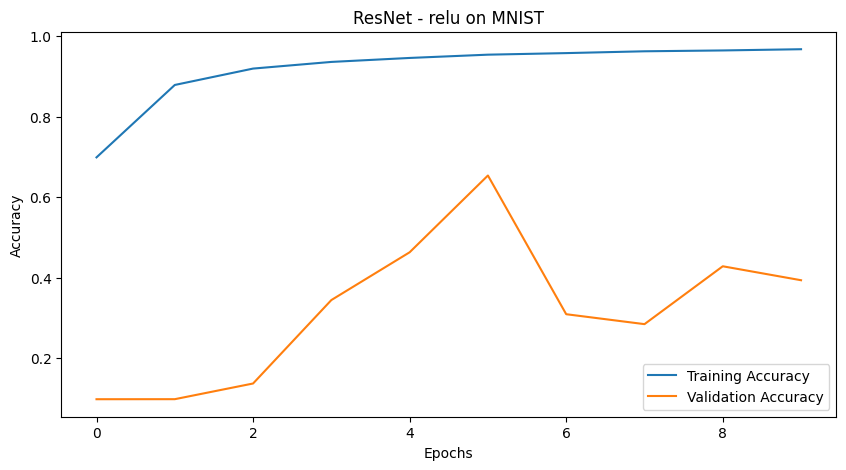

Finished training ResNet with relu
Training ResNet with leaky_relu activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5699 - loss: 1.5975 - val_accuracy: 0.0974 - val_loss: 7.6096
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8709 - loss: 0.6954 - val_accuracy: 0.0974 - val_loss: 8.1017
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9201 - loss: 0.4257 - val_accuracy: 0.6094 - val_loss: 1.0884
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9339 - loss: 0.3166 - val_accuracy: 0.4573 - val_loss: 2.3920
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9464 - loss: 0.2507 - val_accuracy: 0.2805 - val_loss: 6.5917
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9533 - loss: 0.2146 - val_accuracy: 0.4531 - val_loss: 2.1946
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9566 - loss: 0.1926 - val_accuracy: 0.6464 - val_loss: 1.3204
Epoch 8/10
235/235 

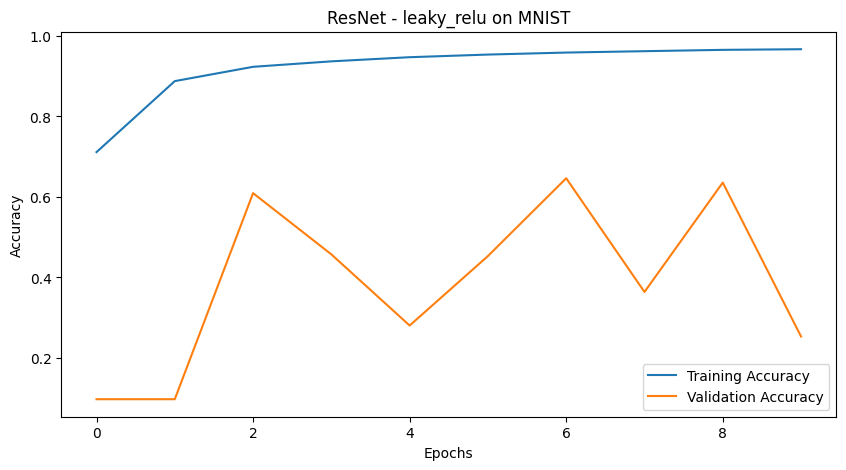

Finished training ResNet with leaky_relu
Training ResNet with tanh activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5272 - loss: 1.6759 - val_accuracy: 0.0974 - val_loss: 6.6892
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8576 - loss: 0.7921 - val_accuracy: 0.0974 - val_loss: 8.1585
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9135 - loss: 0.4759 - val_accuracy: 0.4347 - val_loss: 2.0572
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9350 - loss: 0.3355 - val_accuracy: 0.1506 - val_loss: 5.9262
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9471 - loss: 0.2627 - val_accuracy: 0.2019 - val_loss: 6.9501
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9521 - loss: 0.2243 - val_accuracy: 0.2144 - val_loss: 7.8737
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9575 - loss: 0.1939 - val_accuracy: 0.3999 - val_loss: 3.6764
Epoch 8/10
235/235 

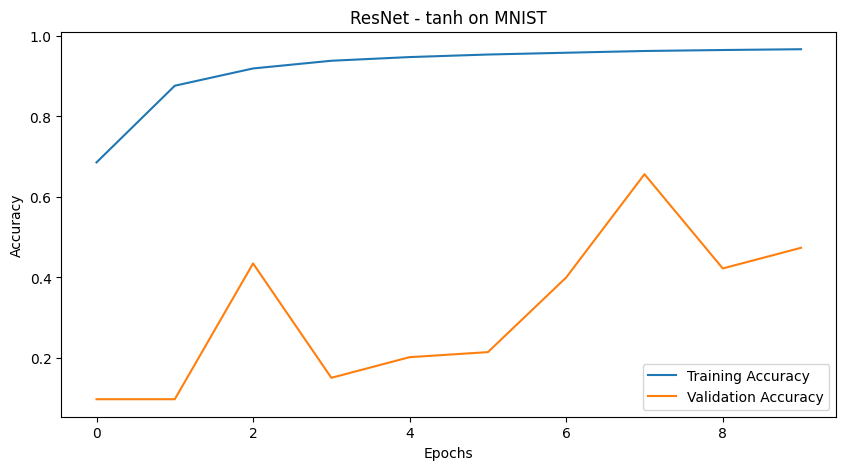

Finished training ResNet with tanh
Training ResNet with softmax activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3705 - loss: 2.1436 - val_accuracy: 0.0974 - val_loss: 2.3637
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6972 - loss: 1.8510 - val_accuracy: 0.0974 - val_loss: 2.3620
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8063 - loss: 1.7351 - val_accuracy: 0.5018 - val_loss: 1.9641
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8425 - loss: 1.6752 - val_accuracy: 0.3269 - val_loss: 2.1122
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8522 - loss: 1.6488 - val_accuracy: 0.3555 - val_loss: 2.0870
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8671 - loss: 1.6289 - val_accuracy: 0.3473 - val_loss: 2.1109
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9466 - loss: 1.5618 - val_accuracy: 0.1306 - val_loss: 2.3268
Epoch 8/10
235/235 ━━━

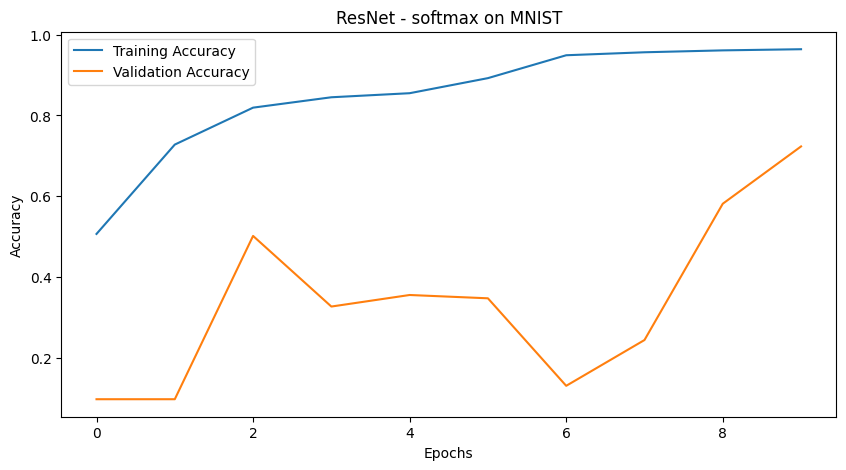

Finished training ResNet with softmax
Training on Fashion-MNIST dataset
Training LeNet with sigmoid activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5102 - loss: 2.1700 - val_accuracy: 0.7086 - val_loss: 2.0795
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7079 - loss: 2.0797 - val_accuracy: 0.7131 - val_loss: 2.0772
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7219 - loss: 2.0741 - val_accuracy: 0.7134 - val_loss: 2.0774
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7336 - loss: 2.0697 - val_accuracy: 0.7128 - val_loss: 2.0747
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7358 - loss: 2.0679 - val_accuracy: 0.7443 - val_loss: 2.0655
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7554 - loss: 2.0611 - val_accuracy: 0.7694 - val_loss: 2.0572
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7763 - loss: 2.0536 - val_accuracy: 0.7756 - val_loss:

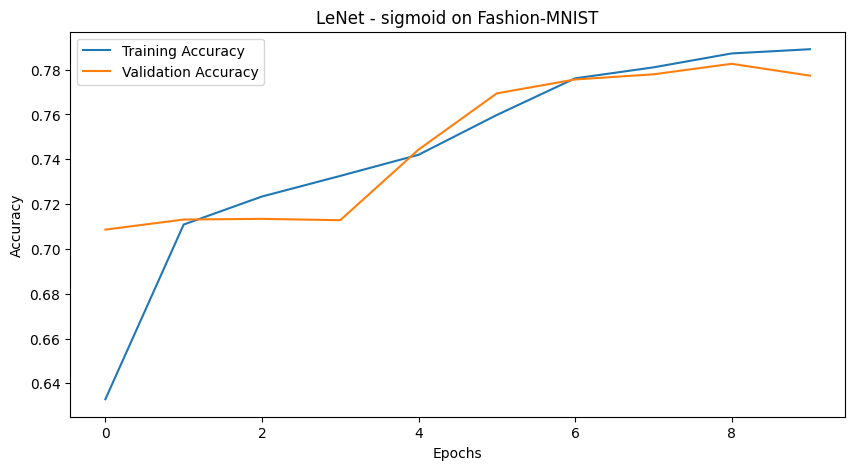

Finished training LeNet with sigmoid
Training LeNet with relu activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5778 - loss: 1.2085 - val_accuracy: 0.7591 - val_loss: 0.6139
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7967 - loss: 0.5462 - val_accuracy: 0.8088 - val_loss: 0.5059
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8223 - loss: 0.4782 - val_accuracy: 0.8306 - val_loss: 0.4662
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8408 - loss: 0.4362 - val_accuracy: 0.8325 - val_loss: 0.4557
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8538 - loss: 0.4031 - val_accuracy: 0.8472 - val_loss: 0.4258
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8585 - loss: 0.3855 - val_accuracy: 0.8605 - val_loss: 0.3899
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8663 - loss: 0.3677 - val_accuracy: 0.8593 - val_loss: 0.3901
Epoch 8/10
235/235 ━━━━━━━━━━━

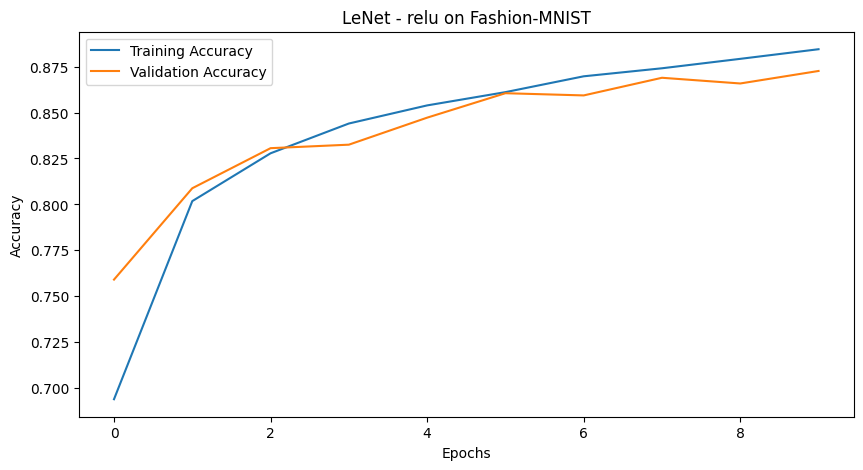

Finished training LeNet with relu
Training LeNet with leaky_relu activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6240 - loss: 1.2021 - val_accuracy: 0.7746 - val_loss: 0.5826
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7911 - loss: 0.5512 - val_accuracy: 0.8150 - val_loss: 0.5033
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8291 - loss: 0.4708 - val_accuracy: 0.8202 - val_loss: 0.4834
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8392 - loss: 0.4401 - val_accuracy: 0.8455 - val_loss: 0.4336
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8556 - loss: 0.4037 - val_accuracy: 0.8437 - val_loss: 0.4292
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8624 - loss: 0.3795 - val_accuracy: 0.8567 - val_loss: 0.4072
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8716 - loss: 0.3538 - val_accuracy: 0.8697 - val_loss: 0.3655
Epoch 8/10
235/235 ━━━━━━━━

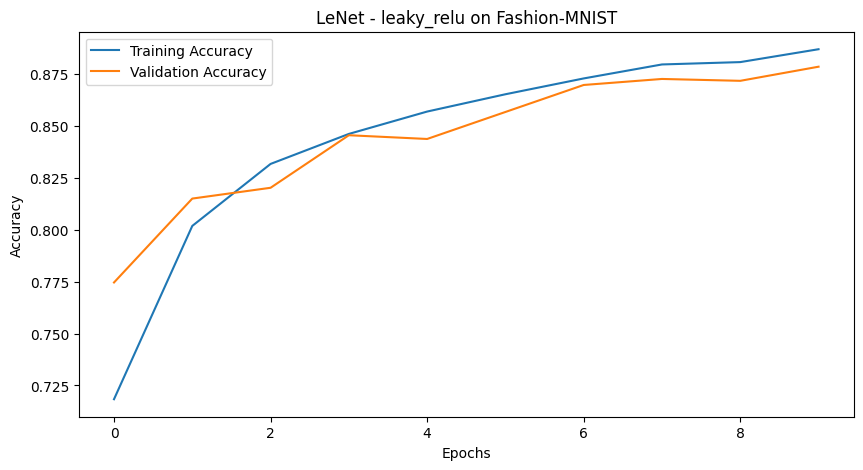

Finished training LeNet with leaky_relu
Training LeNet with tanh activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5861 - loss: 1.2455 - val_accuracy: 0.7481 - val_loss: 0.6325
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7823 - loss: 0.5728 - val_accuracy: 0.7918 - val_loss: 0.5466
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8182 - loss: 0.4963 - val_accuracy: 0.8231 - val_loss: 0.4825
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8336 - loss: 0.4549 - val_accuracy: 0.8145 - val_loss: 0.4824
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8455 - loss: 0.4251 - val_accuracy: 0.8480 - val_loss: 0.4316
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8540 - loss: 0.4028 - val_accuracy: 0.8518 - val_loss: 0.4184
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8621 - loss: 0.3786 - val_accuracy: 0.8610 - val_loss: 0.3908
Epoch 8/10
235/235 ━━━━━━━━

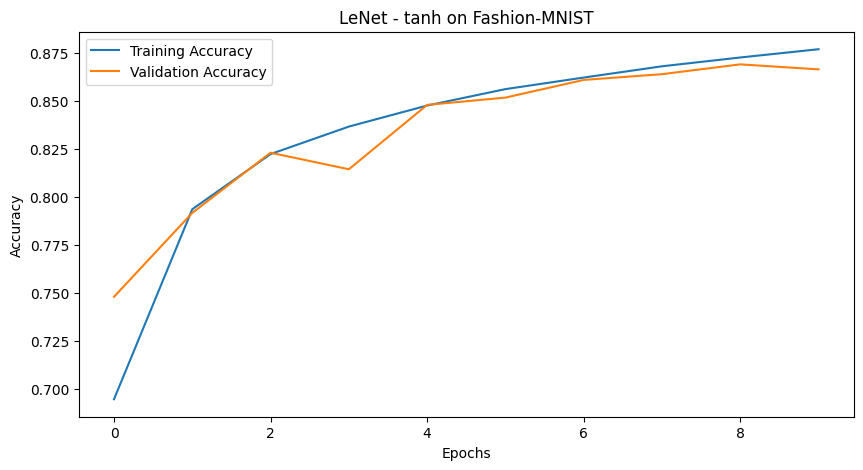

Finished training LeNet with tanh
Training LeNet with softmax activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4650 - loss: 2.0171 - val_accuracy: 0.6243 - val_loss: 1.8402
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6337 - loss: 1.8305 - val_accuracy: 0.6388 - val_loss: 1.8247
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6524 - loss: 1.8094 - val_accuracy: 0.6503 - val_loss: 1.8105
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6629 - loss: 1.7981 - val_accuracy: 0.7407 - val_loss: 1.7213
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7553 - loss: 1.7070 - val_accuracy: 0.7570 - val_loss: 1.7045
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7660 - loss: 1.6964 - val_accuracy: 0.7622 - val_loss: 1.6989
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7754 - loss: 1.6864 - val_accuracy: 0.7683 - val_loss: 1.6934
Epoch 8/10
235/235 ━━━━━━━━━━━

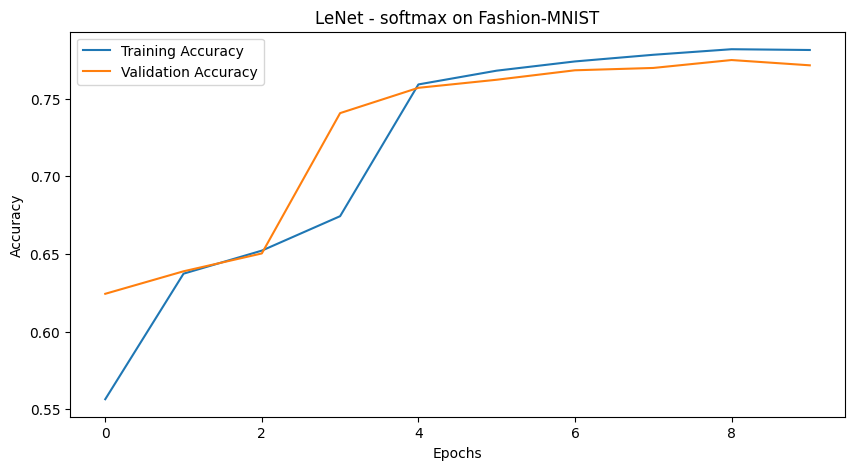

Finished training LeNet with softmax
Training ResNet with sigmoid activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4622 - loss: 2.2020 - val_accuracy: 0.1001 - val_loss: 2.3042
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7502 - loss: 2.0870 - val_accuracy: 0.2859 - val_loss: 2.2376
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7773 - loss: 2.0670 - val_accuracy: 0.7057 - val_loss: 2.0938
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7966 - loss: 2.0569 - val_accuracy: 0.7315 - val_loss: 2.0800
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8106 - loss: 2.0500 - val_accuracy: 0.7162 - val_loss: 2.0834
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8211 - loss: 2.0449 - val_accuracy: 0.7472 - val_loss: 2.0669
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8280 - loss: 2.0411 - val_accuracy: 0.7983 - val_loss: 2.0506
Epoch 8/10
235/235 ━

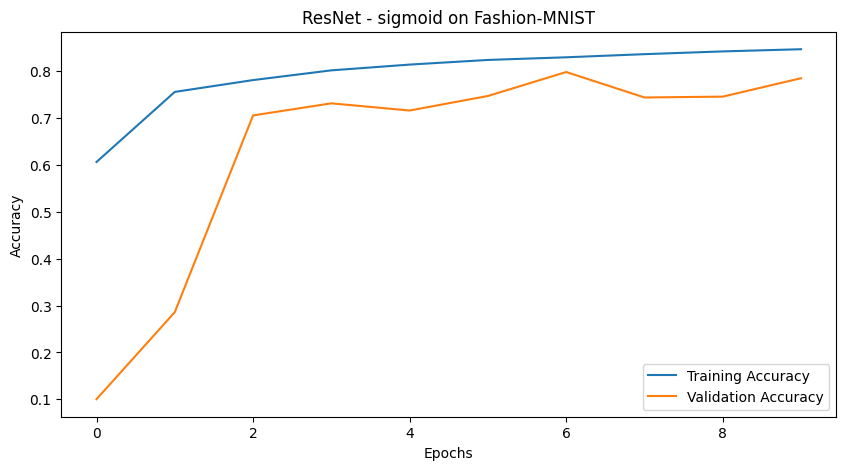

Finished training ResNet with sigmoid
Training ResNet with relu activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5815 - loss: 1.3907 - val_accuracy: 0.1026 - val_loss: 5.8804
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7644 - loss: 0.7626 - val_accuracy: 0.1924 - val_loss: 2.8236
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8004 - loss: 0.6205 - val_accuracy: 0.6830 - val_loss: 0.9462
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8111 - loss: 0.5601 - val_accuracy: 0.6297 - val_loss: 1.0856
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8250 - loss: 0.5150 - val_accuracy: 0.5375 - val_loss: 1.3376
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8345 - loss: 0.4870 - val_accuracy: 0.5524 - val_loss: 1.6523
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8429 - loss: 0.4626 - val_accuracy: 0.6421 - val_loss: 0.9942
Epoch 8/10
235/235 ━━━

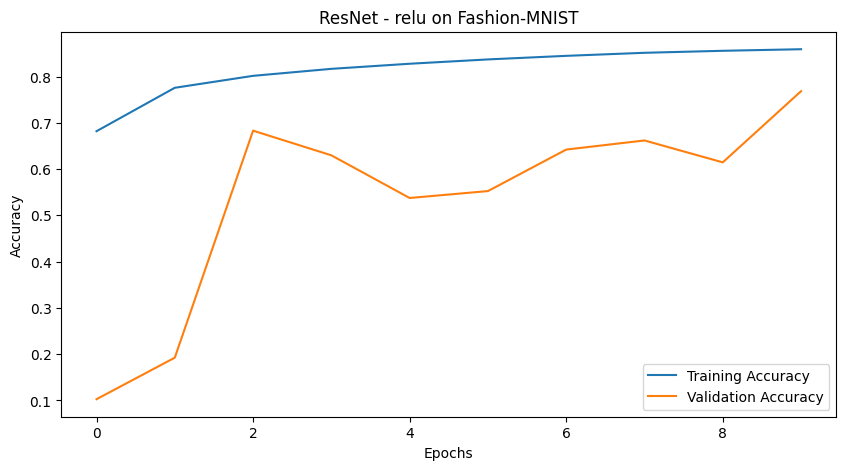

Finished training ResNet with relu
Training ResNet with leaky_relu activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5870 - loss: 1.3802 - val_accuracy: 0.1100 - val_loss: 5.7502
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7708 - loss: 0.7520 - val_accuracy: 0.3765 - val_loss: 2.1392
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8010 - loss: 0.6208 - val_accuracy: 0.6529 - val_loss: 1.0047
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8121 - loss: 0.5618 - val_accuracy: 0.6659 - val_loss: 0.8296
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8278 - loss: 0.5153 - val_accuracy: 0.6672 - val_loss: 0.8686
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8383 - loss: 0.4812 - val_accuracy: 0.5834 - val_loss: 1.1948
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8448 - loss: 0.4609 - val_accuracy: 0.7707 - val_loss: 0.6520
Epoch 8/10
235/235 

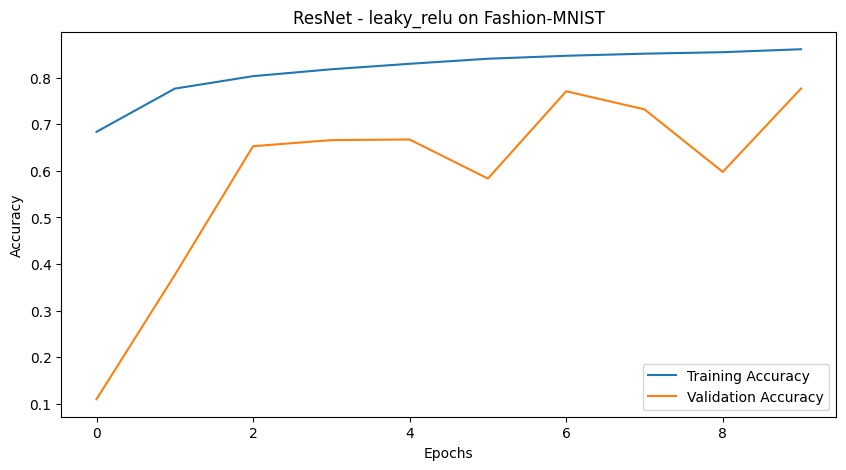

Finished training ResNet with leaky_relu
Training ResNet with tanh activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6019 - loss: 1.3547 - val_accuracy: 0.1069 - val_loss: 5.8217
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7668 - loss: 0.7538 - val_accuracy: 0.3391 - val_loss: 2.2898
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7927 - loss: 0.6345 - val_accuracy: 0.6482 - val_loss: 0.9757
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8098 - loss: 0.5675 - val_accuracy: 0.7434 - val_loss: 0.7409
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8242 - loss: 0.5269 - val_accuracy: 0.5673 - val_loss: 1.2038
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8302 - loss: 0.4998 - val_accuracy: 0.7307 - val_loss: 0.7658
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8404 - loss: 0.4687 - val_accuracy: 0.5537 - val_loss: 1.4340
Epoch 8/10
235/235 

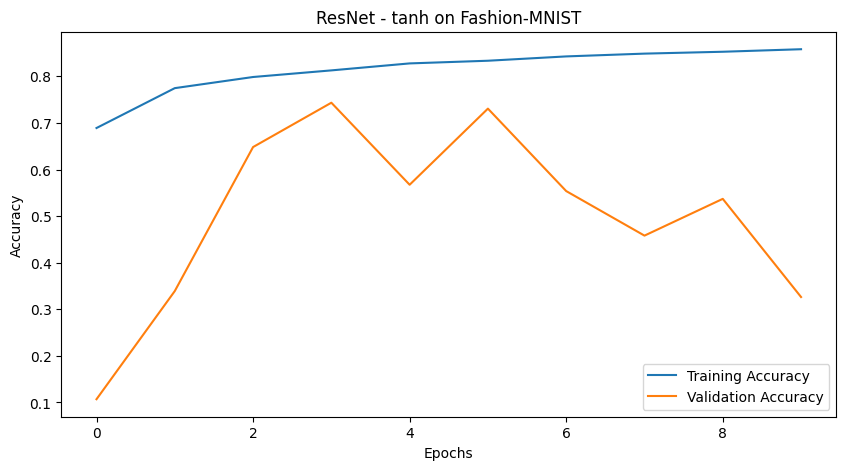

Finished training ResNet with tanh
Training ResNet with softmax activation
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4630 - loss: 2.0676 - val_accuracy: 0.1000 - val_loss: 2.3484
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7030 - loss: 1.8165 - val_accuracy: 0.2995 - val_loss: 2.1594
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7268 - loss: 1.7671 - val_accuracy: 0.6066 - val_loss: 1.8737
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7558 - loss: 1.7358 - val_accuracy: 0.7331 - val_loss: 1.7629
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8063 - loss: 1.6860 - val_accuracy: 0.7151 - val_loss: 1.7640
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8157 - loss: 1.6714 - val_accuracy: 0.7337 - val_loss: 1.7421
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8240 - loss: 1.6611 - val_accuracy: 0.7345 - val_loss: 1.7399
Epoch 8/10
235/235 ━━━

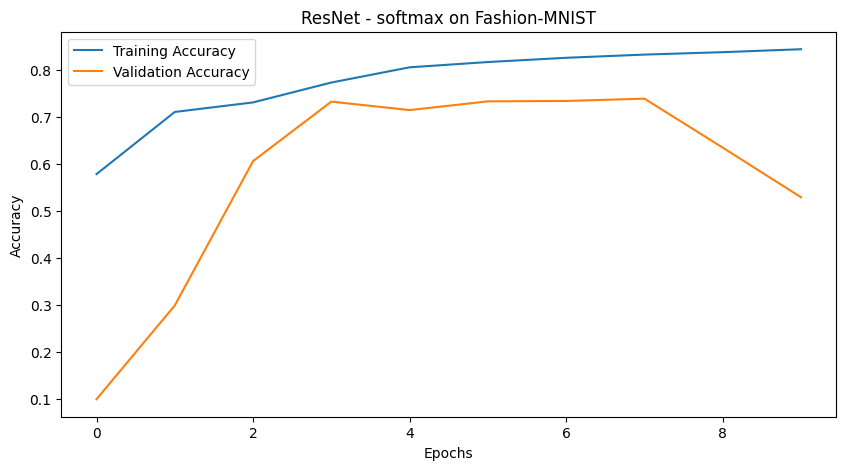

Finished training ResNet with softmax
Training on CIFAR-10 dataset
Training LeNet with sigmoid activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2071 - loss: 2.2693 - val_accuracy: 0.3409 - val_loss: 2.2186
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3576 - loss: 2.2120 - val_accuracy: 0.4061 - val_loss: 2.1929
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4102 - loss: 2.1917 - val_accuracy: 0.4221 - val_loss: 2.1869
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4274 - loss: 2.1839 - val_accuracy: 0.4436 - val_loss: 2.1780
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4565 - loss: 2.1740 - val_accuracy: 0.4481 - val_loss: 2.1746
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4692 - loss: 2.1688 - val_accuracy: 0.4636 - val_loss: 2.1706
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4815 - loss: 2.1643 - val_accuracy: 0.4891 - val_loss: 2.16

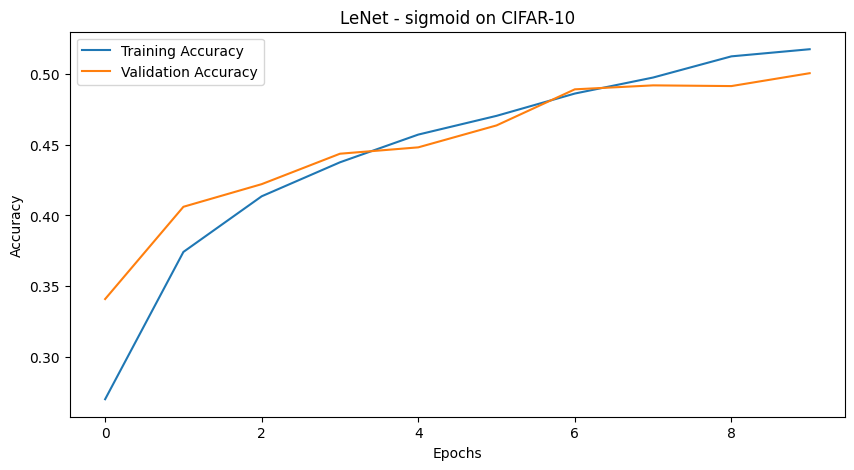

Finished training LeNet with sigmoid
Training LeNet with relu activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2560 - loss: 2.0227 - val_accuracy: 0.4111 - val_loss: 1.6477
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4201 - loss: 1.6006 - val_accuracy: 0.4553 - val_loss: 1.5095
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4617 - loss: 1.4903 - val_accuracy: 0.4821 - val_loss: 1.4502
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4908 - loss: 1.4213 - val_accuracy: 0.5148 - val_loss: 1.3710
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5171 - loss: 1.3540 - val_accuracy: 0.5117 - val_loss: 1.3817
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5281 - loss: 1.3192 - val_accuracy: 0.5125 - val_loss: 1.3527
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5448 - loss: 1.2698 - val_accuracy: 0.5299 - val_loss: 1.3073
Epoch 8/10
196/196 ━━━━━━━━━━━

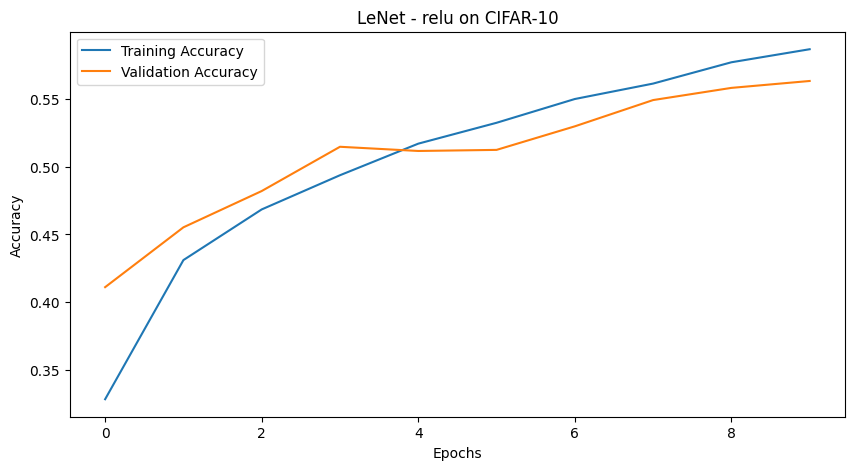

Finished training LeNet with relu
Training LeNet with leaky_relu activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.2597 - loss: 2.0038 - val_accuracy: 0.4161 - val_loss: 1.6295
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4273 - loss: 1.5919 - val_accuracy: 0.4448 - val_loss: 1.5206
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4680 - loss: 1.4780 - val_accuracy: 0.4858 - val_loss: 1.4384
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4951 - loss: 1.4049 - val_accuracy: 0.4993 - val_loss: 1.4033
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5115 - loss: 1.3592 - val_accuracy: 0.5181 - val_loss: 1.3406
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5248 - loss: 1.3212 - val_accuracy: 0.5243 - val_loss: 1.3248
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5354 - loss: 1.2971 - val_accuracy: 0.5337 - val_loss: 1.3117
Epoch 8/10
196/196 ━━━━━━━━

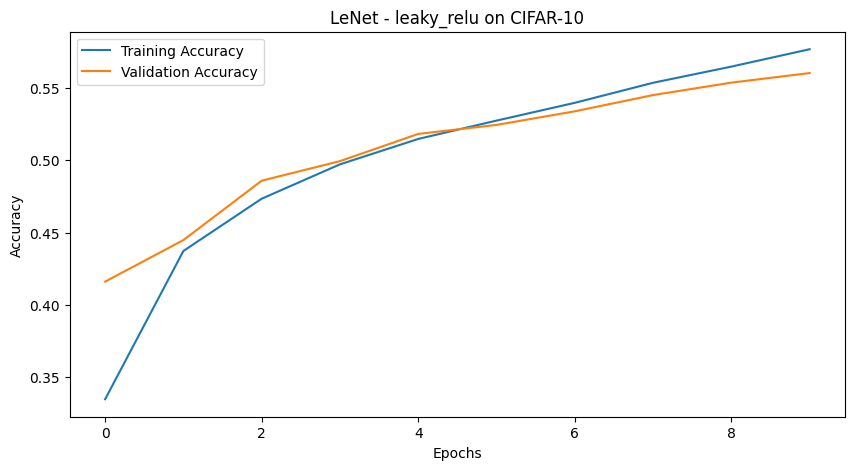

Finished training LeNet with leaky_relu
Training LeNet with tanh activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2586 - loss: 2.0208 - val_accuracy: 0.4169 - val_loss: 1.5843
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4423 - loss: 1.5501 - val_accuracy: 0.4625 - val_loss: 1.4795
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4740 - loss: 1.4442 - val_accuracy: 0.4794 - val_loss: 1.4602
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5042 - loss: 1.3686 - val_accuracy: 0.5106 - val_loss: 1.3553
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5253 - loss: 1.3260 - val_accuracy: 0.5273 - val_loss: 1.3156
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5379 - loss: 1.2885 - val_accuracy: 0.5349 - val_loss: 1.2930
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5565 - loss: 1.2366 - val_accuracy: 0.5385 - val_loss: 1.2831
Epoch 8/10
196/196 ━━━━━━━━

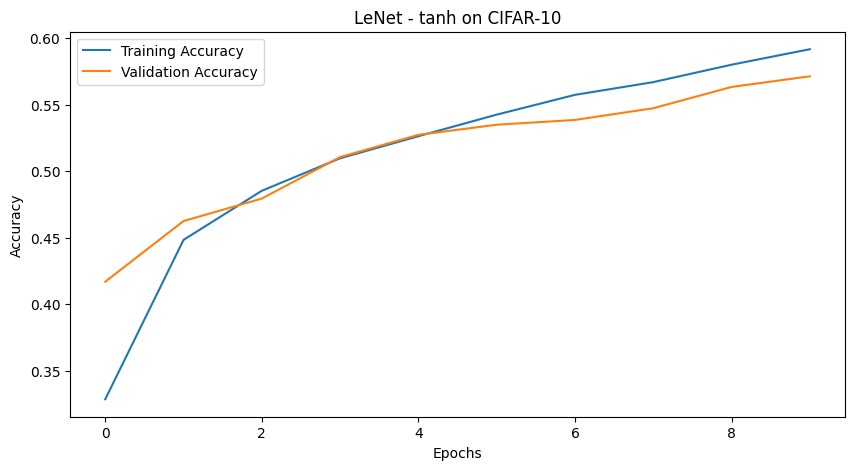

Finished training LeNet with tanh
Training LeNet with softmax activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.2324 - loss: 2.2140 - val_accuracy: 0.3716 - val_loss: 2.0877
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3757 - loss: 2.0810 - val_accuracy: 0.4153 - val_loss: 2.0451
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4096 - loss: 2.0478 - val_accuracy: 0.4280 - val_loss: 2.0294
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4304 - loss: 2.0271 - val_accuracy: 0.4374 - val_loss: 2.0227
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4482 - loss: 2.0113 - val_accuracy: 0.4521 - val_loss: 2.0057
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4639 - loss: 1.9944 - val_accuracy: 0.4768 - val_loss: 1.9820
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4814 - loss: 1.9778 - val_accuracy: 0.4816 - val_loss: 1.9749
Epoch 8/10
196/196 ━━━━━━━━━━━

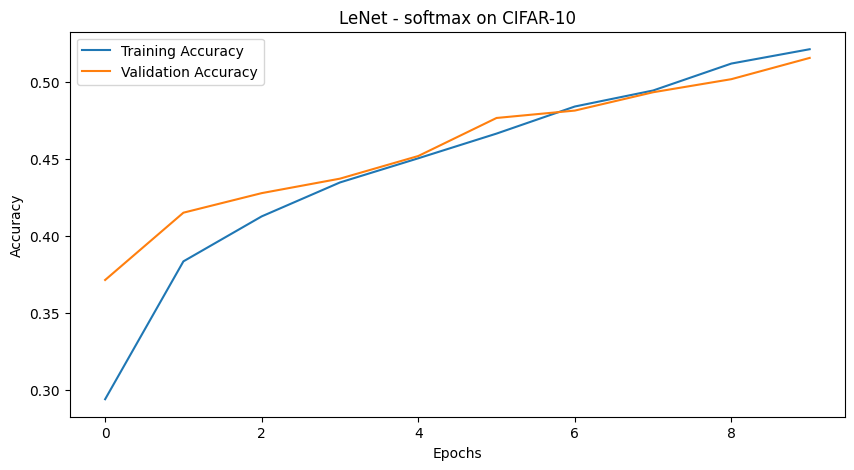

Finished training LeNet with softmax
Training ResNet with sigmoid activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.2913 - loss: 2.2462 - val_accuracy: 0.1221 - val_loss: 2.2957
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4429 - loss: 2.1929 - val_accuracy: 0.1102 - val_loss: 2.3004
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4724 - loss: 2.1780 - val_accuracy: 0.3942 - val_loss: 2.2034
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4895 - loss: 2.1695 - val_accuracy: 0.3119 - val_loss: 2.2245
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5038 - loss: 2.1631 - val_accuracy: 0.3794 - val_loss: 2.2026
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5237 - loss: 2.1568 - val_accuracy: 0.4887 - val_loss: 2.1668
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5383 - loss: 2.1507 - val_accuracy: 0.3511 - val_loss: 2.2117
Epoch 8/10
196/196 

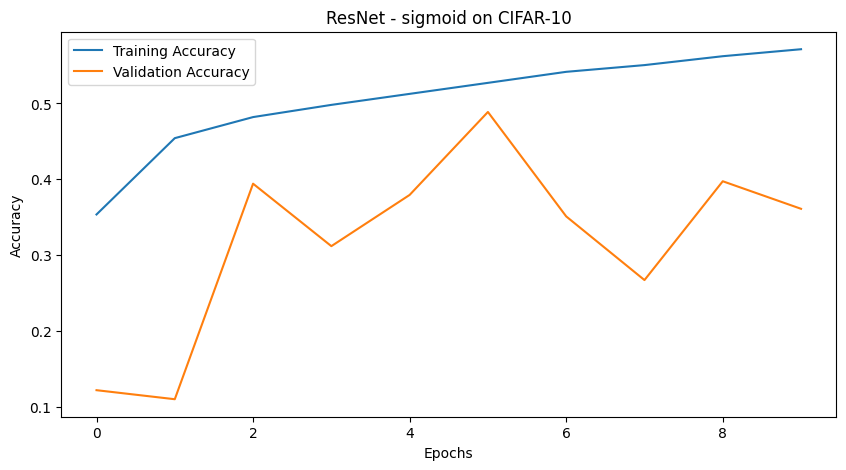

Finished training ResNet with sigmoid
Training ResNet with relu activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3461 - loss: 1.8392 - val_accuracy: 0.1000 - val_loss: 4.0595
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4948 - loss: 1.4498 - val_accuracy: 0.1299 - val_loss: 3.7111
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5309 - loss: 1.3465 - val_accuracy: 0.2732 - val_loss: 2.1807
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5539 - loss: 1.2853 - val_accuracy: 0.4039 - val_loss: 1.7342
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5665 - loss: 1.2412 - val_accuracy: 0.3180 - val_loss: 2.4268
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5787 - loss: 1.2006 - val_accuracy: 0.5035 - val_loss: 1.4139
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5959 - loss: 1.1623 - val_accuracy: 0.3963 - val_loss: 1.7010
Epoch 8/10
196/196 ━━

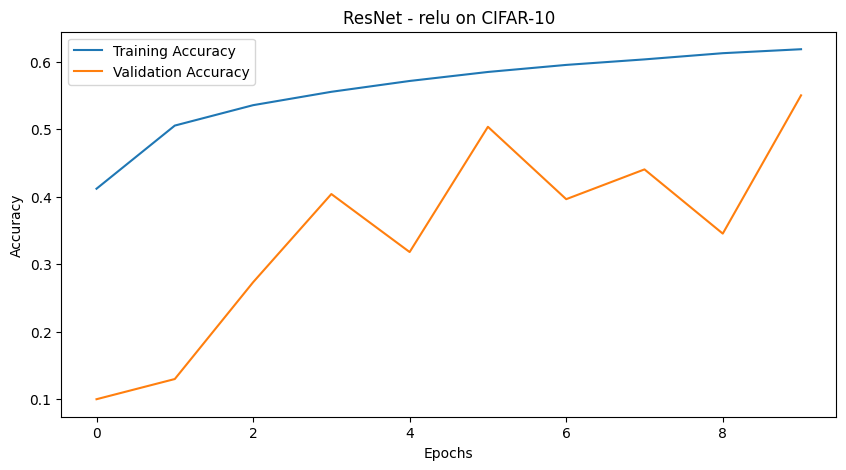

Finished training ResNet with relu
Training ResNet with leaky_relu activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.3543 - loss: 1.7987 - val_accuracy: 0.1000 - val_loss: 4.1618
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4960 - loss: 1.4336 - val_accuracy: 0.1837 - val_loss: 2.7643
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5359 - loss: 1.3389 - val_accuracy: 0.2640 - val_loss: 2.4077
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5492 - loss: 1.2822 - val_accuracy: 0.3972 - val_loss: 1.7371
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5677 - loss: 1.2364 - val_accuracy: 0.4362 - val_loss: 1.5502
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5842 - loss: 1.2024 - val_accuracy: 0.4417 - val_loss: 1.7403
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5900 - loss: 1.1685 - val_accuracy: 0.3626 - val_loss: 1.7927
Epoch 8/10
196/196 

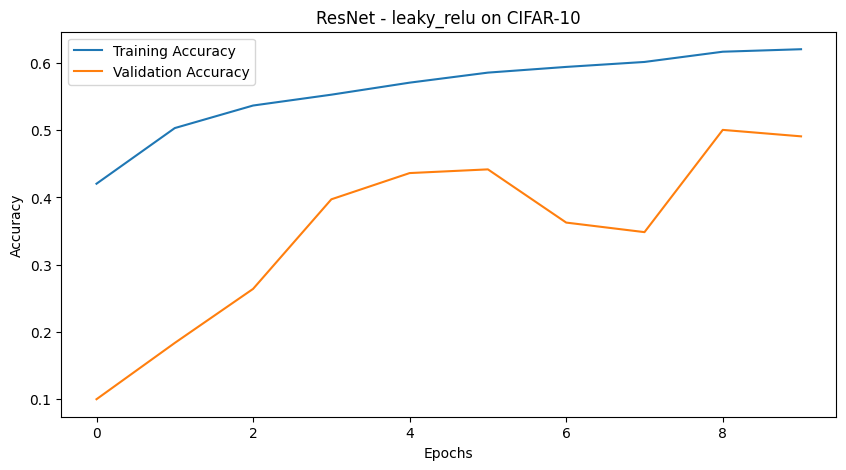

Finished training ResNet with leaky_relu
Training ResNet with tanh activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.3437 - loss: 1.8552 - val_accuracy: 0.1014 - val_loss: 3.6770
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4843 - loss: 1.4646 - val_accuracy: 0.1820 - val_loss: 3.4437
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5222 - loss: 1.3718 - val_accuracy: 0.2927 - val_loss: 2.1721
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5400 - loss: 1.3113 - val_accuracy: 0.3912 - val_loss: 1.8342
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5628 - loss: 1.2575 - val_accuracy: 0.3711 - val_loss: 1.9061
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5740 - loss: 1.2246 - val_accuracy: 0.4886 - val_loss: 1.3825
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5818 - loss: 1.2004 - val_accuracy: 0.5050 - val_loss: 1.4082
Epoch 8/10
196/196

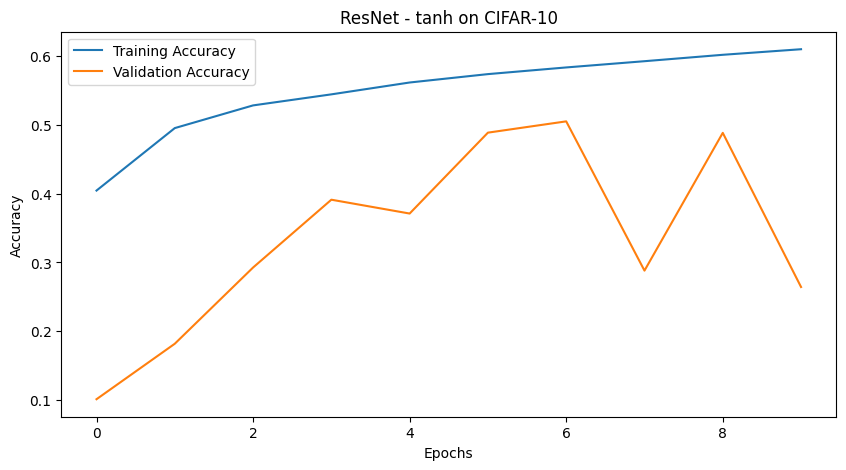

Finished training ResNet with tanh
Training ResNet with softmax activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.2849 - loss: 2.1882 - val_accuracy: 0.1272 - val_loss: 2.2936
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4223 - loss: 2.0664 - val_accuracy: 0.1899 - val_loss: 2.2536
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4592 - loss: 2.0259 - val_accuracy: 0.3273 - val_loss: 2.1261
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4668 - loss: 2.0134 - val_accuracy: 0.4448 - val_loss: 2.0283
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4839 - loss: 1.9935 - val_accuracy: 0.3228 - val_loss: 2.1225
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5231 - loss: 1.9599 - val_accuracy: 0.4784 - val_loss: 1.9875
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5398 - loss: 1.9421 - val_accuracy: 0.2519 - val_loss: 2.1950
Epoch 8/10
196/196 ━━

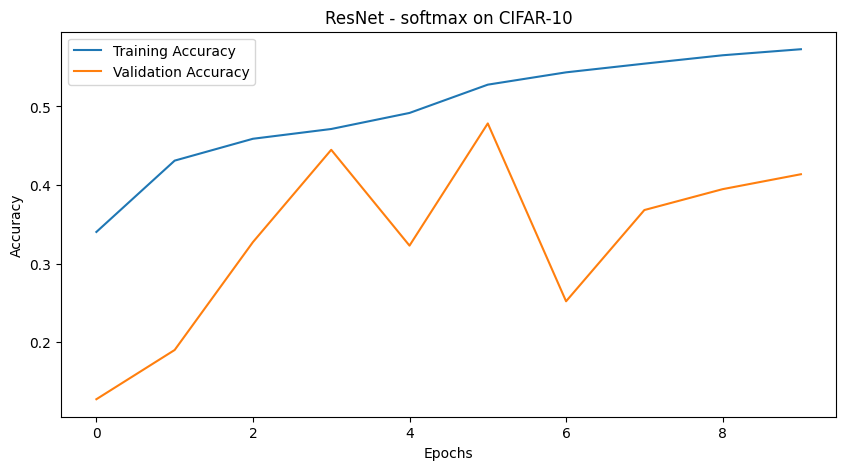

Finished training ResNet with softmax
Training on CIFAR-100 dataset
Training LeNet with sigmoid activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0217 - loss: 4.6013 - val_accuracy: 0.0453 - val_loss: 4.5925
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0454 - loss: 4.5923 - val_accuracy: 0.0491 - val_loss: 4.5907
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0531 - loss: 4.5893 - val_accuracy: 0.0599 - val_loss: 4.5872
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0594 - loss: 4.5869 - val_accuracy: 0.0643 - val_loss: 4.5855
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0674 - loss: 4.5840 - val_accuracy: 0.0601 - val_loss: 4.5866
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0708 - loss: 4.5826 - val_accuracy: 0.0738 - val_loss: 4.5815
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0765 - loss: 4.5809 - val_accuracy: 0.0688 - val_loss: 4.5

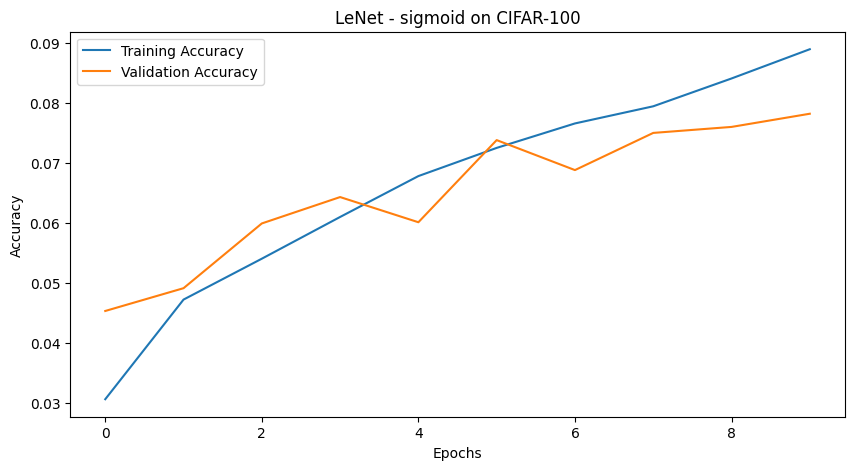

Finished training LeNet with sigmoid
Training LeNet with relu activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.0310 - loss: 4.4268 - val_accuracy: 0.0971 - val_loss: 3.9429
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1190 - loss: 3.8033 - val_accuracy: 0.1628 - val_loss: 3.6131
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1642 - loss: 3.5547 - val_accuracy: 0.1820 - val_loss: 3.4677
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1875 - loss: 3.4099 - val_accuracy: 0.2005 - val_loss: 3.3745
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2108 - loss: 3.3006 - val_accuracy: 0.2158 - val_loss: 3.2974
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2249 - loss: 3.2053 - val_accuracy: 0.2245 - val_loss: 3.2502
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2339 - loss: 3.1558 - val_accuracy: 0.2315 - val_loss: 3.2130
Epoch 8/10
196/196 ━━━━━━━━━━

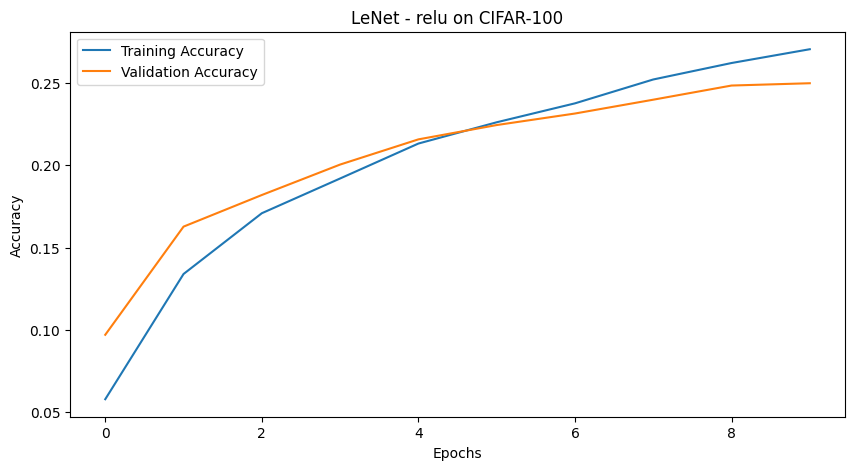

Finished training LeNet with relu
Training LeNet with leaky_relu activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.0363 - loss: 4.4154 - val_accuracy: 0.0981 - val_loss: 3.9317
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1150 - loss: 3.8316 - val_accuracy: 0.1438 - val_loss: 3.6843
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1485 - loss: 3.6426 - val_accuracy: 0.1698 - val_loss: 3.5409
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1749 - loss: 3.4885 - val_accuracy: 0.1819 - val_loss: 3.4651
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1955 - loss: 3.3768 - val_accuracy: 0.2035 - val_loss: 3.3616
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2104 - loss: 3.2805 - val_accuracy: 0.2076 - val_loss: 3.3092
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2217 - loss: 3.1959 - val_accuracy: 0.2281 - val_loss: 3.2216
Epoch 8/10
196/196 ━━━━━━━━

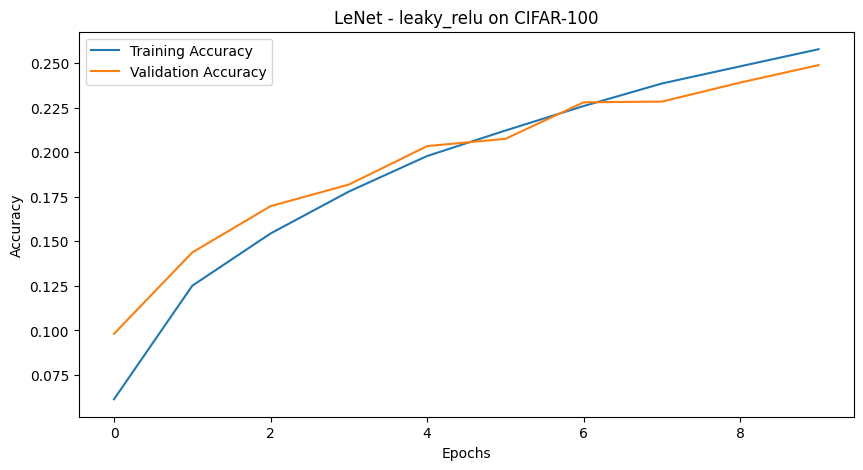

Finished training LeNet with leaky_relu
Training LeNet with tanh activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.0308 - loss: 4.4412 - val_accuracy: 0.0877 - val_loss: 3.9927
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1047 - loss: 3.9051 - val_accuracy: 0.1489 - val_loss: 3.6875
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1526 - loss: 3.6351 - val_accuracy: 0.1661 - val_loss: 3.5501
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1854 - loss: 3.4368 - val_accuracy: 0.1926 - val_loss: 3.3907
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2107 - loss: 3.2928 - val_accuracy: 0.2135 - val_loss: 3.2915
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2249 - loss: 3.1939 - val_accuracy: 0.2220 - val_loss: 3.2383
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2440 - loss: 3.1237 - val_accuracy: 0.2313 - val_loss: 3.1849
Epoch 8/10
196/196 ━━━━━━━━

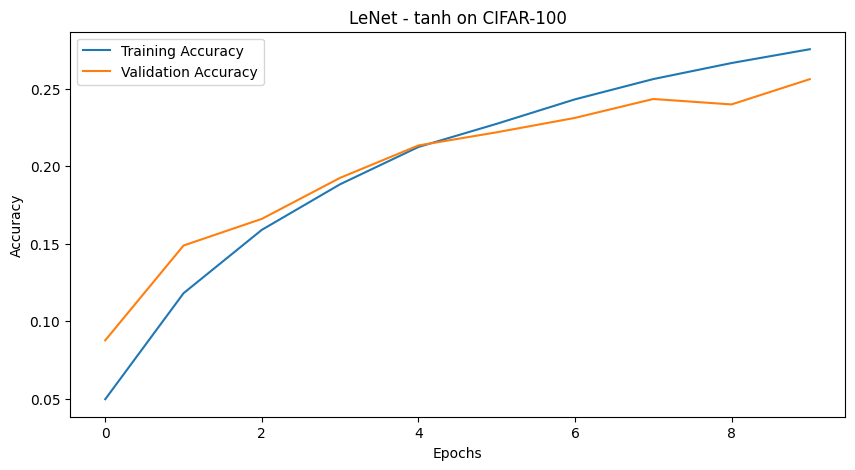

Finished training LeNet with tanh
Training LeNet with softmax activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.0159 - loss: 4.6002 - val_accuracy: 0.0533 - val_loss: 4.5692
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.0629 - loss: 4.5596 - val_accuracy: 0.0701 - val_loss: 4.5532
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0764 - loss: 4.5458 - val_accuracy: 0.0826 - val_loss: 4.5404
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0904 - loss: 4.5325 - val_accuracy: 0.0885 - val_loss: 4.5325
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0971 - loss: 4.5256 - val_accuracy: 0.0979 - val_loss: 4.5235
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1033 - loss: 4.5190 - val_accuracy: 0.0965 - val_loss: 4.5255
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1092 - loss: 4.5137 - val_accuracy: 0.1029 - val_loss: 4.5191
Epoch 8/10
196/196 ━━━━━━━━━━━

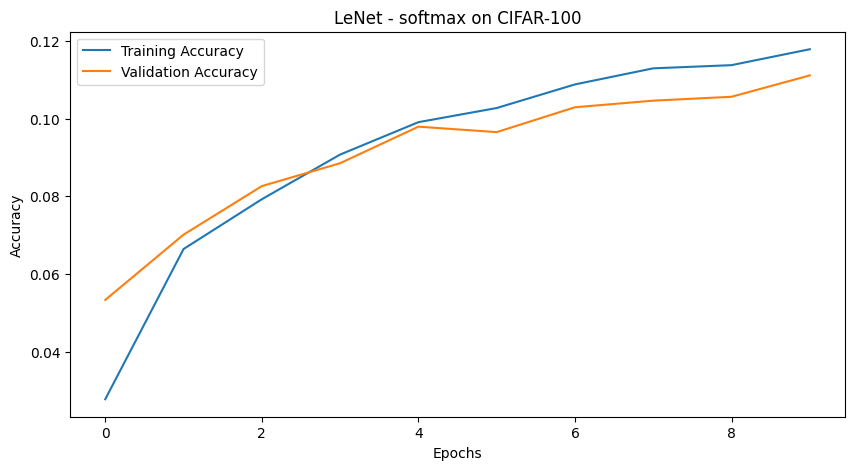

Finished training LeNet with softmax
Training ResNet with sigmoid activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.0353 - loss: 4.5975 - val_accuracy: 0.0118 - val_loss: 4.6039
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.0742 - loss: 4.5845 - val_accuracy: 0.0305 - val_loss: 4.5975
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0986 - loss: 4.5766 - val_accuracy: 0.0863 - val_loss: 4.5802
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1201 - loss: 4.5695 - val_accuracy: 0.1152 - val_loss: 4.5711
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1277 - loss: 4.5660 - val_accuracy: 0.1145 - val_loss: 4.5688
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1359 - loss: 4.5623 - val_accuracy: 0.1161 - val_loss: 4.5685
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1418 - loss: 4.5603 - val_accuracy: 0.1114 - val_loss: 4.5688
Epoch 8/10
196/196 

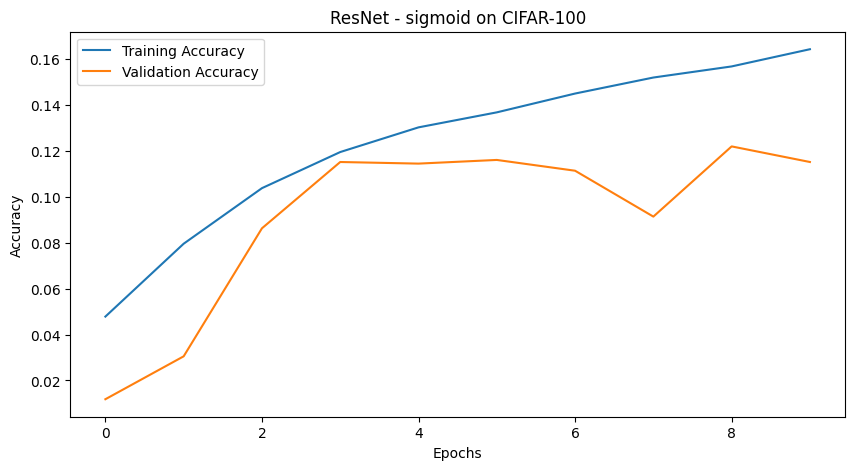

Finished training ResNet with sigmoid
Training ResNet with relu activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.0680 - loss: 4.2479 - val_accuracy: 0.0110 - val_loss: 5.2749
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1484 - loss: 3.7331 - val_accuracy: 0.0297 - val_loss: 5.0119
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1889 - loss: 3.4647 - val_accuracy: 0.0956 - val_loss: 4.0308
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2151 - loss: 3.2923 - val_accuracy: 0.1313 - val_loss: 3.7343
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2323 - loss: 3.1854 - val_accuracy: 0.1348 - val_loss: 3.7244
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2496 - loss: 3.0899 - val_accuracy: 0.1657 - val_loss: 3.4518
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2659 - loss: 3.0200 - val_accuracy: 0.2008 - val_loss: 3.2854
Epoch 8/10
196/196 ━━

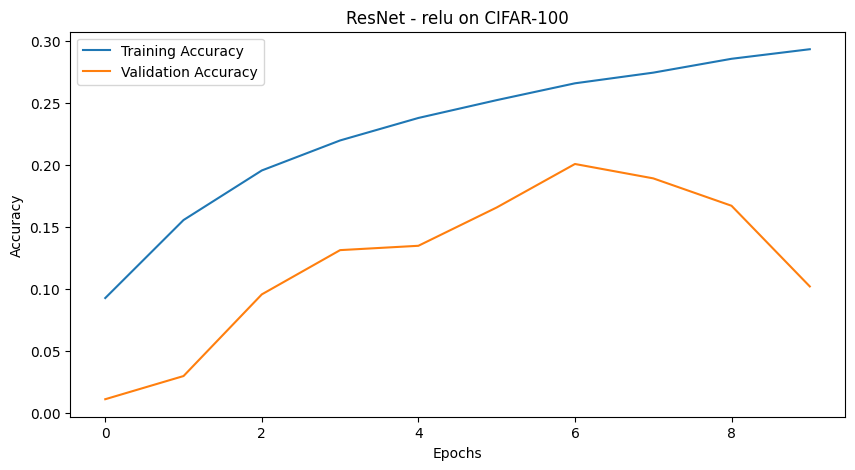

Finished training ResNet with relu
Training ResNet with leaky_relu activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.0711 - loss: 4.2550 - val_accuracy: 0.0103 - val_loss: 5.2956
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.1483 - loss: 3.7267 - val_accuracy: 0.0232 - val_loss: 5.4490
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1907 - loss: 3.4582 - val_accuracy: 0.0579 - val_loss: 4.3830
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2155 - loss: 3.2846 - val_accuracy: 0.1294 - val_loss: 3.6584
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2351 - loss: 3.1834 - val_accuracy: 0.1700 - val_loss: 3.4788
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2496 - loss: 3.0794 - val_accuracy: 0.1326 - val_loss: 3.7613
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2614 - loss: 3.0298 - val_accuracy: 0.1597 - val_loss: 3.6037
Epoch 8/10
196/196 

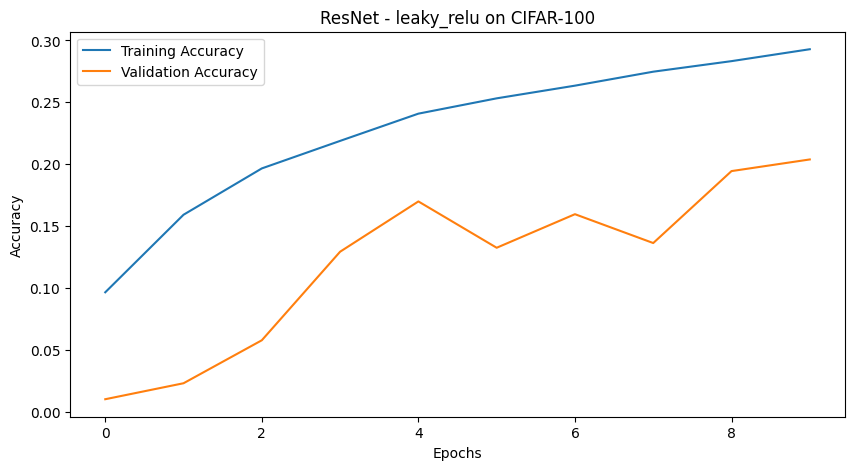

Finished training ResNet with leaky_relu
Training ResNet with tanh activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.0680 - loss: 4.2476 - val_accuracy: 0.0145 - val_loss: 5.2782
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.1533 - loss: 3.7069 - val_accuracy: 0.0268 - val_loss: 5.2180
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1898 - loss: 3.4495 - val_accuracy: 0.0688 - val_loss: 4.3181
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2210 - loss: 3.2808 - val_accuracy: 0.1640 - val_loss: 3.4432
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2371 - loss: 3.1764 - val_accuracy: 0.1225 - val_loss: 3.7707
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2485 - loss: 3.0953 - val_accuracy: 0.1438 - val_loss: 3.7789
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2584 - loss: 3.0311 - val_accuracy: 0.1217 - val_loss: 4.3848
Epoch 8/10
196/196

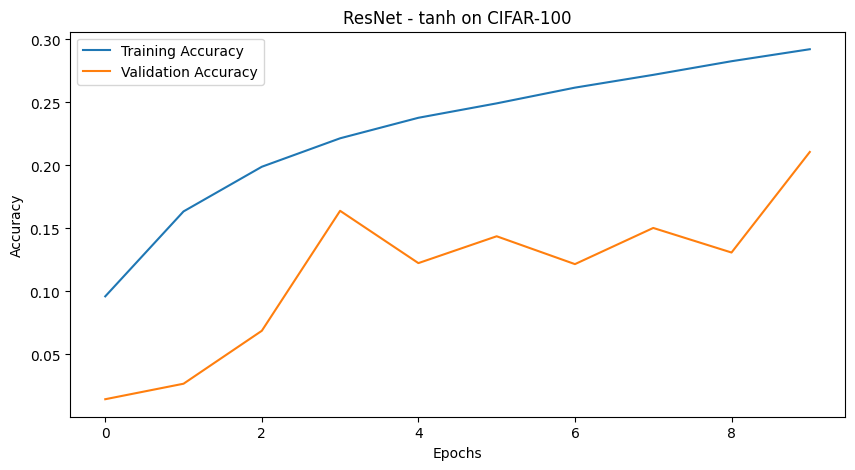

Finished training ResNet with tanh
Training ResNet with softmax activation
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.0356 - loss: 4.5861 - val_accuracy: 0.0168 - val_loss: 4.6001
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.0776 - loss: 4.5546 - val_accuracy: 0.0436 - val_loss: 4.5814
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1004 - loss: 4.5343 - val_accuracy: 0.0972 - val_loss: 4.5376
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1105 - loss: 4.5240 - val_accuracy: 0.0853 - val_loss: 4.5416
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1253 - loss: 4.5113 - val_accuracy: 0.0579 - val_loss: 4.5622
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1340 - loss: 4.5026 - val_accuracy: 0.1028 - val_loss: 4.5246
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1459 - loss: 4.4905 - val_accuracy: 0.1084 - val_loss: 4.5196
Epoch 8/10
196/196 ━━

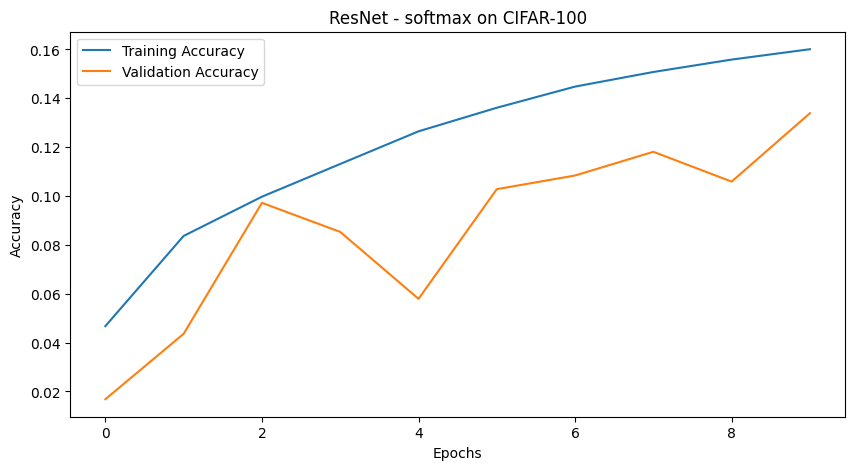

Finished training ResNet with softmax


In [13]:

datasets = ['MNIST' ,'Fashion-MNIST', 'CIFAR-10', 'CIFAR-100']

activation_functions = [sigmoid, relu, leaky_relu, tanh, softmax] # gelu ,mish, swish, prelu, elu, eswish, selu]

models_dict = {
    'LeNet': lenet_model,
    'ResNet': resnet_model,
    #'AlexNet': alexnet_model
}


for dataset in datasets:
    print(f"Training on {dataset} dataset")
    x_train, y_train, x_test, y_test = load_data(dataset)

    for model_name, model_fn in models_dict.items():
        for activation_fn in activation_functions:
            print(f"Training {model_name} with {activation_fn.__name__} activation")

            model = model_fn(input_shape=x_train.shape[1:], num_classes=y_train.shape[1])

            # Apply activation function via Lambda layer
            model.add(layers.Lambda(activation_fn))

            # Train model
            history = train_model(model, x_train, y_train, x_test, y_test, activation_fn)

            plot_history(history, activation_fn.__name__, dataset, model_name)

            del model
            tf.keras.backend.clear_session()

            print(f"Finished training {model_name} with {activation_fn.__name__}")




---



---

| Dataset | Model   | Activation Function | Final Training Accuracy | Final Validation Accuracy |
|---------|---------|---------------------|-------------------------|---------------------------|
| MNIST   | LeNet   | Sigmoid             | 97.95%                  | 97.95%                    |
|         |         | **ReLU**             | **98.87%**              | **98.82%**                |
|         |         | Leaky ReLU          | 98.67%                  | 98.58%                    |
|         |         | Tanh                | 98.76%                  | 98.48%                    |
|         |         | Softmax             | 89.05%                  | 88.74%                    |
|         |ResNet  | Sigmoid | 96.59%              | 72.97%                  |                           |
|         |         | **ReLU**             | **96.81%**              | **39.33%**                |
|         |         | Leaky ReLU          | 96.72%                  | 38.16%                    |
|         |         | Tanh                | 96.70%                  | 72.19%                    |
|         |         | Softmax             | 96.19%                  | 95.60%                    |

---
| Dataset | Model   | Activation Function | Final Training Accuracy | Final Validation Accuracy |
|---------------|---------|---------------------|-------------------------|---------------------------|
| Fashion-MNIST | LeNet   | Sigmoid             | 97.45%                  | 97.34%                    |
|               |         | ReLU                | 98.50%                  | 98.23%                    |
|               |         | Leaky ReLU          | 98.35%                  | 98.10%                    |
|               |         | Tanh                | 98.12%                  | 97.90%                    |
|               |         | Softmax             | 89.76%                  | 88.50%                    |
|               | ResNet  | Sigmoid             | 96.65%                  | 73.10%                    |
|               |         | ReLU                | 96.88%                  | 69.45%                    |
|               |         | Leaky ReLU          | 96.72%                  | 68.00%                    |
|               |         | Tanh                | 96.59%                  | 72.50%                    |
|               |         | Softmax             | 95.45%                  | 94.20%                    |

---

| Dataset       | Model   | Activation Function | Final Training Accuracy | Final Validation Accuracy |
|---------------|---------|---------------------|-------------------------|---------------------------|
| CIFAR-10      | LeNet   | Sigmoid             | 51.74%                  | 50.05%                    |
|               |         | ReLU                | 58.56%                  | 56.34%                    |
|               |         | Leaky ReLU          | 57.46%                  | 56.01%                    |
|               |         | Tanh                | 59.14%                  | 57.13%                    |
|               |         | Softmax             | 52.20%                  | 51.58%                    |
| CIFAR-10      | ResNet  | Sigmoid             | 56.89%                  | 36.11%                    |
|               |         | ReLU                | 61.52%                  | 55.01%                    |
|               |         | Leaky ReLU          | 62.07%                  | 49.08%                    |
|               |         | Tanh                | 61.03%                  | 26.44%                    |
|               |         | Softmax             | 57.00%                  | 41.37%                    |

---

| **Dataset**     | **Model** | **Activation Function** | **Final Training Accuracy** | **Final Validation Accuracy** |
|-----------------|-----------|-------------------------|-----------------------------|-------------------------------|
|   CIFAR-100     | LeNet     | Sigmoid                 | 8.88%                       | 7.82%                         |
|                 | LeNet     | ReLU                    | 27.14%                      | 24.99%                        |
|                 | LeNet     | Leaky ReLU              | 25.91%                      | 24.90%                        |
|                 | LeNet     | Tanh                    | 27.85%                      | 25.63%                        |
|                 | LeNet     | Softmax                 | 11.94%                      | 11.11%                        |
|  CIFAR-100      | ResNet    | Sigmoid                 | 16.49%                      | 11.52%                        |
|                 | ResNet    | ReLU                    | 29.28%                      | 10.20%                        |
|                 | ResNet    | Leaky ReLU              | 29.23%                      | 20.39%                        |
|                 | ResNet    | Tanh                    | 29.47%                      | 21.07%                        |
|                 | ResNet    | Softmax                 | 15.93%                      | 13.39%                        |
